# Feature extraction methods
We look at the SIFT and ORB algorithms for extracting features in images. There is also SURF, but it is not open-sourced.

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [51]:
# Load images to illustrate methods
img1 = cv2.imread('/Users/anandadide/Documents/GitHub/ComputerVision-Glossary/images/dog_img1.png')
img2 = cv2.imread('/Users/anandadide/Documents/GitHub/ComputerVision-Glossary/images/dog_img2.png')

## SIFT: Scale Invariant Feature Transform


SIFT works in the following way for an image:

1) Gaussian blurring at different scales: Blur for image scaled to different sizes to create more "stable" features i.e. can be matched even if they differ in detail
2) Candidate scale-invariant features based on intensity "spikes": Subtract blurred images, keypoints are local max/min found when comparing to neighbouring blurred profiles.
3) Remove uninteresting features: Features are uninteresting if they are a) low-contrast: based on a threshold, or b) edge-like: feature likely to be an edge if you can draw a line where intensity changes sharply
4) Candidate rotation-invariant features based on intensity "changes": Compute intensity gradients and identify the dominant gradient direction.
5) Convert features into compact numerical descriptors: Represent the intensity "spikes" and "changes" as a vector.

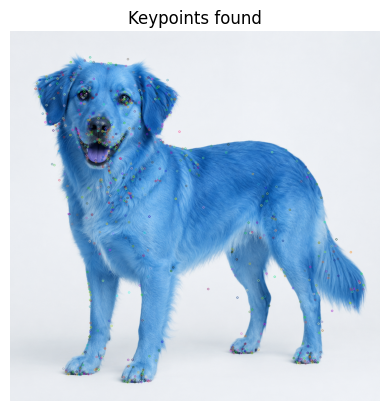

In [52]:
"""
Extract features in one image.
"""
# Initialize SIFT extractor
sift = cv2.SIFT_create()

# Convert RGB to grayscale: since SIFT is concerned with intensities
img_gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# Use SIFT to find features in image
keypoints1, descriptors1 = sift.detectAndCompute(img_gray1, None)

# Visualize keypoints
keypoints_on_img1 = cv2.drawKeypoints(img1, keypoints1, None, flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)

plt.imshow(keypoints_on_img1) 
plt.title("Keypoints found")
plt.axis('off')  
plt.show()

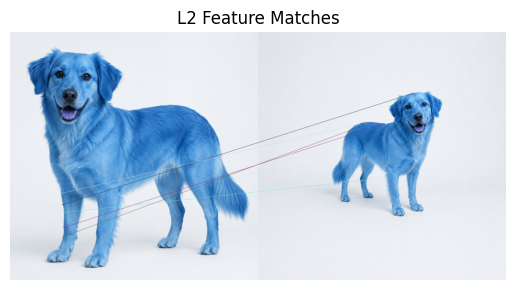

In [ ]:
"""
Extract features in two images, then match them using descriptors.
"""
# Extract features in image 2
img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
keypoints2, descriptors2 = sift.detectAndCompute(img_gray2, None)

## Feature matching using euclidean distance (L2 norm)
bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match keypoint descriptors between images, rank matches by ascending distance (best matches)
matches = bf_matcher.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Visualize keypoint matches, we keep top 5 matches for better visualization
matches_img = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:5], None, flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(matches_img) 
plt.title("L2 Feature Matches")
plt.axis('off')  
plt.show()

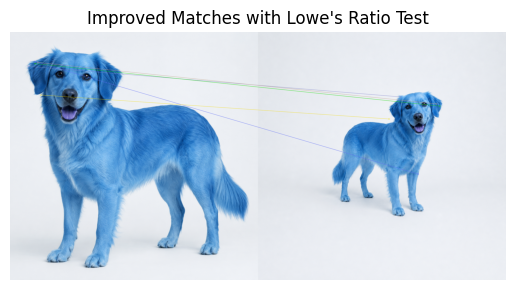

In [59]:
"""
Previous feature matching is not very good, because cross-checking is strict (matches have to be mutual). 
To get better matches, switch off cross-checking and use knn + Lowe's ratio test for more flexible matching.
"""
# Switch off cross-checking and use knn
bf_matcher = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = bf_matcher.knnMatch(descriptors1, descriptors2, k=2)

# Apply Lowe's ratio test to filter good matches, usually between 0.7 and 0.8
ratio_thresh = 0.75
improved_matches = []
for i, j in knn_matches:
    if i.distance < ratio_thresh * j.distance:
        improved_matches.append(i)

# Visualize improved matches
improved_matches_img = cv2.drawMatches(img1, keypoints1, img2, keypoints2, improved_matches[:5], None, flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(improved_matches_img) 
plt.title("Improved Matches with Lowe's Ratio Test")
plt.axis('off')  
plt.show()

## ORB: Speeded-Up Robust Features


ORB works in the following way for an image:

1) "Corner-like" features using FAST: Detect interesting keypoints by looking for center pixels surrounded by darker pixels for a group of pixels.
2) Candidate scale-invariant features: Similar to what SIFT does, runs step 1 on differently scaled image then record features found at each scale.
3) Remove uninteresting features: Rank and keep only best ones using Harris corner score. The idea is a "corner" is distinctive if you shift it horizontally/vertically and there is significant changes in intensity. 
4) Candidate rotation-invariant features: Similar to what SIFT does, but tags the "dominant" direction as the direction from each feature's center to the brightest centroid.
5) Convert features into compact numerical descriptors using BRIEF: Choose 2 pixels around each keypoint and compare intensity, representing them as binary numbers.


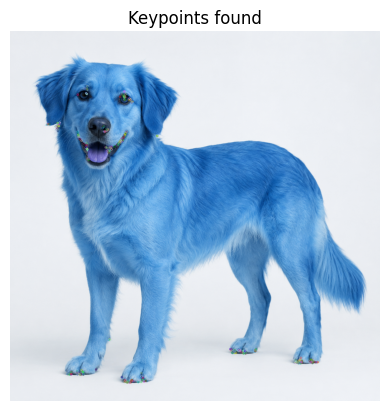

In [60]:
"""
Extract features in one image.
"""
# Initialize ORB extractor
orb = cv2.ORB_create()

# Use ORB to find features in image
keypoints1, descriptors1 = orb.detectAndCompute(img1, None)

# Visualize keypoints
keypoints_on_img1 = cv2.drawKeypoints(img1, keypoints1, None, flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)

plt.imshow(keypoints_on_img1) 
plt.title("Keypoints found")
plt.axis('off')  
plt.show()

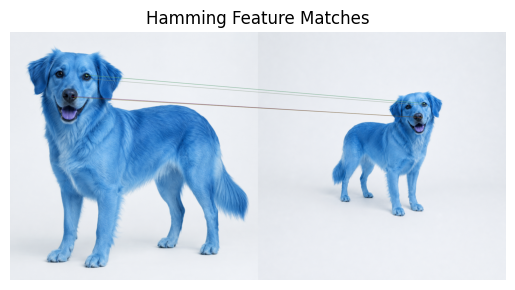

In [63]:
"""
Extract features in two images, then match them using descriptors.
"""
# Extract features in image 2
keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

## Feature matching using euclidean distance (L2 norm)
bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match keypoint descriptors between images, use Hamming distance since descriptors are binary
bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Visualize keypoint matches, we keep top 5 matches for better visualization
matches_img = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:5], None, flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(matches_img) 
plt.title("Hamming Feature Matches")
plt.axis('off')  
plt.show()

## Considerations

1) Image type for feature extraction
ORB looks for "corner-like features", which does not do well on images that are not textured or if images are particularly noisy with many background features. Use SIFT if you require more robust feature extraction.

2) Time/Compute
ORB leverages on faster algorithms to extract features compared to SIFT, and represent keypoint descriptors in a more compact representation compared to SIFT. Use ORB if you require a lightweight and fast way for feature extraction.